# ERC-4626: all vaults on Arbitrum

- In this notebook, we examine ERC-4626 vaults on a particular chain

## Usage

This is an open source notebook based on open data
- You can edit and remix this notebook yourself 

To do your own data research:

- Read general instructions [how to run the tutorials](./)
- See `ERC-4626: scanning vaults' historical price and performance` example in tutorials first how to build `vault-prices-1h.parquet` file.

For any questions, follow and contact [Trading Strategy community](https://tradingstrategy.ai/community).

## Setup

- Set up notebook rendering output mode
- Use static image charts so this notebook is readeable on Github / ReadTheDocs

In [1]:
import pandas as pd
from plotly.offline import init_notebook_mode
import plotly.io as pio

from eth_defi.vault.base import VaultSpec
from eth_defi.research.notebook import set_large_plotly_chart_font

# Fix X time axis bugs in Plotly charts
from eth_defi.monkeypatch import plotly

pd.options.display.float_format = "{:,.2f}".format
pd.options.display.max_columns = None
pd.options.display.max_rows = None


# Set up Plotly chart output as SVG
image_format = "png"
width = 1400
height = 800

# https://stackoverflow.com/a/52956402/315168
init_notebook_mode()

# https://plotly.com/python/renderers/#overriding-the-default-renderer
pio.renderers.default = image_format

current_renderer = pio.renderers[image_format]
# Have SVGs default pixel with
current_renderer.width = width
current_renderer.height = height

# Set all Plotly charts to use large font sizes for better readability,
# for sharing on mobile
set_large_plotly_chart_font(line_width=5, legend_font_size=16)
pio.templates.default = "custom"

## Read and clean raw scanned vault price data

- Read the Parquet file produced earlier with price scan 
- Clean the data if necessary

In [2]:
import pickle
from pathlib import Path

from eth_defi.vault.vaultdb import VaultDatabase

data_folder = Path("~/.tradingstrategy/vaults").expanduser()

vault_db = VaultDatabase.read()

cleaned_data_parquet_file = data_folder / "cleaned-vault-prices-1h.parquet"
prices_df = pd.read_parquet(cleaned_data_parquet_file)

print(f"We have {len(vault_db):,} vaults in the database and {len(prices_df):,} price rows.")

We have 26,856 vaults in the database and 5,992,906 price rows.


## Choose chain to examine

- [See ChainList.org](https://chainlist.org/)

In [3]:
from eth_defi.vault.base import VaultSpec
from eth_defi.chain import get_chain_name

selected_chain_id = 42161  # Arbitrum
# selected_chain_id = 1  # Ethereum Mainnet
chain_name = get_chain_name(selected_chain_id)

print(f"Examining chain {chain_name} ({selected_chain_id})")


Examining chain Arbitrum (42161)


## Price data filtering

- Filter rices for our chains only

In [4]:

# last_sample_at = prices_df.index[-1]
# one_month_ago = last_sample_at - pd.DateOffset(months=1)

# PERIOD = [
#    one_month_ago,
#    last_sample_at,
#]
#
# mask = (prices_df.index >= PERIOD[0]) & (prices_df.index <= PERIOD[1])
prices_df = prices_df[prices_df["chain"] == selected_chain_id]
print(f"Examined prices contain {len(prices_df):,} price rows across all vaults on {chain_name}.")

prices_df.head(4)

Examined prices contain 399,501 price rows across all vaults on Arbitrum.


,id,chain,address,block_number,share_price,total_assets,total_supply,performance_fee,management_fee,errors,name,event_count,protocol,raw_share_price,returns_1h,avg_assets_by_vault,dynamic_tvl_threshold,tvl_filtering_mask
timestamp,,,,,,,,,,,,,,,,,,
2025-08-20 10:45:30,42161-0x000a70c4887cc3974de7535623209ca01a215c50,42161,0x000a70c4887cc3974de7535623209ca01a215c50,370385921,1.00,1.33,1.33,NaN,NaN,,Harvest: USDC Vault (0x000A),5,Harvest Finance,1.00,0.00,1.34,0.03,True
2025-08-27 14:29:29,42161-0x000a70c4887cc3974de7535623209ca01a215c50,42161,0x000a70c4887cc3974de7535623209ca01a215c50,372862721,1.00,1.34,1.33,NaN,NaN,,Harvest: USDC Vault (0x000A),5,Harvest Finance,1.00,0.00,1.34,0.03,True
2025-12-10 19:39:45,42161-0x000a70c4887cc3974de7535623209ca01a215c50,42161,0x000a70c4887cc3974de7535623209ca01a215c50,409265921,1.00,1.34,1.33,NaN,NaN,,Harvest: USDC Vault (0x000A),5,Harvest Finance,1.00,0.00,1.34,0.03,True
2025-12-25 01:09:32,42161-0x000a70c4887cc3974de7535623209ca01a215c50,42161,0x000a70c4887cc3974de7535623209ca01a215c50,414190721,1.00,1.34,1.33,NaN,NaN,,Harvest: USDC Vault (0x000A),5,Harvest Finance,1.00,0.00,1.34,0.03,True


## Filter vaults

- Choose vaults on our chain
- Filter out junk entries

In [5]:
min_tvl = 50_000

vault_db_chain = {spec: row for spec, row in vault_db.items() if spec.chain_id == selected_chain_id}
vault_db = {spec: row for spec, row in vault_db_chain.items() if (row["NAV"] or 0) >= min_tvl}
selected_vault_ids = {spec.as_string_id() for spec in vault_db.keys()}
prices_df = prices_df.loc[prices_df["id"].isin(selected_vault_ids)]

print(f"We have selectd {len(vault_db)} vaults out of total of {len(vault_db_chain):,} vaults on chain {chain_name}, having {len(prices_df):,} price rows.")

print("An example vault metadata:")
example_vault = next(iter(vault_db.values()))
display(pd.DataFrame(list(example_vault.items()), columns=["Key", "Value"]))

We have selectd 284 vaults out of total of 5,933 vaults on chain Arbitrum, having 128,423 price rows.
An example vault metadata:


,Key,Value
0,Symbol,plvGLP
1,Name,Plutus Vault GLP
2,Address,0x5326e71ff593ecc2cf7acae5fe57582d6e74cff1
3,Denomination,plsGLP
4,Share token,plvGLP
5,NAV,218852.566660400704649665
6,Protocol,<protocol not yet identified>
7,Mgmt fee,None
8,Perf fee,None
9,Deposit fee,None


## Calculate vault lifetime metrics

- Calculate the DataFrame of life time metrics for each vault


In [6]:
from eth_defi.research.vault_metrics import calculate_lifetime_metrics, clean_lifetime_metrics
from eth_defi.research.vault_metrics import format_lifetime_table

lifetime_data_df = calculate_lifetime_metrics(
    prices_df,
    vault_db,
)

print(f"Cleaning metrics for {len(lifetime_data_df):,} vaults")
lifetime_data_df = clean_lifetime_metrics(
    lifetime_data_df,
    max_annualised_return=0.99,  # 99% max return
)

print(f"Calculated lifetime metrics for {len(lifetime_data_df):,} vaults")

lifetime_data_df = lifetime_data_df.sort_values(["one_month_cagr"], ascending=False)

display(lifetime_data_df.head(2))

Calculating vault performance metrics:   0%|          | 0/132 [00:00<?, ?it/s]

Cleaning metrics for 132 vaults
Vault entries with too high NAV values filtered out: 16
Vault entries with too small ATH NAV values filtered out: 0
Vaults abnormally high returns: 6
Vault entries with too few deposit and redeem events (min 25) filtered out: 5
Calculated lifetime metrics for 103 vaults


,name,vault_slug,protocol_slug,share_token_address,denomination_token_address,lifetime_return,lifetime_return_net,cagr,cagr_net,three_months_returns,three_months_returns_net,three_months_cagr,three_months_cagr_net,three_months_sharpe,three_months_sharpe_net,three_months_volatility,one_month_returns,one_month_returns_net,one_month_cagr,one_month_cagr_net,denomination,normalised_denomination,denomination_slug,share_token,chain,peak_nav,current_nav,years,mgmt_fee,perf_fee,deposit_fee,withdraw_fee,fee_mode,fee_internalised,gross_fees,net_fees,fee_label,lockup,event_count,protocol,risk,risk_numeric,id,start_date,end_date,address,chain_id,stablecoinish,first_updated_at,first_updated_block,last_updated_at,last_updated_block,last_share_price,features,flags,notes,link,trading_strategy_link,one_month_start,one_month_end,one_month_samples,three_months_start,three_months_end,three_months_samples,lifetime_start,lifetime_end,lifetime_samples,period_results
15,Ostium Liquidity Pool Vault,ostium-liquidity-pool-vault,ostium,0x20D419a8e12C45f88fDA7c5760bb6923Cee27F98,0xaf88d065e77c8cC2239327C5EDb3A432268e5831,0.13,0.13,0.08,0.08,-0.02,-0.02,-0.07,-0.07,-0.28,-0.28,0.11,0.06,0.06,0.98,0.98,USDC,USDC,usdc,oLP,Arbitrum,"68,090,578.21","30,334,977.42",1.51,0.00,0.00,0.00,0.00,VaultFeeMode.feeless,True,FeeData(fee_mode=<VaultFeeMode.feeless: 'feele...,FeeData(fee_mode=<VaultFeeMode.feeless: 'feele...,0% / 0%,NaT,89157,Ostium,VaultTechnicalRisk.high,30.00,42161-0x20d419a8e12c45f88fda7c5760bb6923cee27f98,2024-07-03 12:44:22,2026-01-05 20:02:59,0x20d419a8e12c45f88fda7c5760bb6923cee27f98,42161,True,2024-07-03 12:44:22,228329921,2026-01-05 20:02:59,418265921,1.13,[ostium_like],{},None,https://routescan.io/address/0x20D419a8e12C45f...,https://tradingstrategy.ai/trading-view/arbitr...,2025-12-05 23:57:30,2026-01-05 20:02:59,129.00,2025-10-07 16:29:09,2026-01-05 20:02:59,389,2024-07-03 12:44:22,2026-01-05 20:02:59,1653,"[PeriodMetrics(period='1W', error_reason=None,..."
120,Curve LLAMMA IBTC / crvUSD,curve-llamma-ibtc-crvusd,llamma,0xe296eE7F83D1d95B3f7827fF1D08Fe1E4cF09d8d,0x498Bf2B1e120FeD3ad3D42EA2165E9b73f99C1e5,0.18,0.18,0.13,0.13,0.11,0.11,0.40,0.40,54.03,54.03,0.01,0.05,0.05,0.81,0.81,crvUSD,CRVUSD,crvusd,cvcrvUSD,Arbitrum,"407,182.92","65,256.35",1.38,0.00,0.00,0.00,0.00,VaultFeeMode.internalised_skimming,True,FeeData(fee_mode=<VaultFeeMode.internalised_sk...,FeeData(fee_mode=<VaultFeeMode.internalised_sk...,0% / 0%,0 days,1482,LLAMMA,VaultTechnicalRisk.blacklisted,999.00,42161-0xe296ee7f83d1d95b3f7827ff1d08fe1e4cf09d8d,2024-08-19 17:01:50,2026-01-05 20:02:59,0xe296ee7f83d1d95b3f7827ff1d08fe1e4cf09d8d,42161,True,2024-08-19 17:01:50,244558721,2026-01-05 20:02:59,418265921,0.00,[llamma_like],{},Vault not actively listed on any known website...,https://www.curve.finance/lend/arbitrum/market...,https://tradingstrategy.ai/trading-view/arbitr...,2025-12-06 12:55:04,2026-01-05 20:02:59,66.00,2025-09-15 16:09:39,2026-01-05 20:02:59,126,2024-08-19 17:01:50,2026-01-05 20:02:59,370,"[PeriodMetrics(period='1W', error_reason=None,..."


## Top vault list

- List top vaults on the chain, formatted for readability



In [7]:
from eth_defi.research.vault_metrics import format_lifetime_table

min_tvl = 25_000

lifetime_data_filtered_df = lifetime_data_df[lifetime_data_df["current_nav"] >= min_tvl]

lifetime_data_filtered_df = lifetime_data_filtered_df.sort_values(["one_month_cagr"], ascending=False)

print(f"Vaults filtered by min TVL of ${min_tvl:,}, remaining {len(lifetime_data_filtered_df):,} vaults.")
formatted_df = format_lifetime_table(
    lifetime_data_filtered_df,
    add_index=True,
    add_address=True,
)

print(f"Last update {lifetime_data_filtered_df['last_updated_at'].max()}")

cols_to_move = ['Name', '1M return ann. (net / gross)']
other_cols = [col for col in formatted_df.columns if col not in cols_to_move]
formatted_df = formatted_df[cols_to_move + other_cols]

print(f"Formatted data for {len(formatted_df):,} vaults.")

# Script output
max_address_dump = 300
head = formatted_df.head(max_address_dump)
vault_count = min(max_address_dump, len(head))
print(f"Top {vault_count} vaults by 1 month annualised return are: {', '.join(head['Name'])}")
print(f"Top {vault_count} vaults by 1 month annualised return are:\n{', '.join(head['Address'])}")

display(formatted_df)


Vaults filtered by min TVL of $25,000, remaining 103 vaults.
Last update 2026-01-06 00:02:43
Formatted data for 99 vaults.
Top 99 vaults by 1 month annualised return are: Ostium Liquidity Pool Vault, Steakhouse High Yield USDT0, Angmar Capital, Gravity Team LTD, Plutus Hedge Token, YieldFi yUSD, Curve LLAMMA asdCRV / crvUSD, Llamarisk crvUSD Vault, USDn2, gTrade (Gains Network USDC), Staked USDai, DAMM Stablecoin Fund, Steakhouse High Yield, USDC-2 yVault, Curve LLAMMA ARB / crvUSD, Yield Chasing crvUSD, Borrowable USDC Deposit, SiloId: 152, Euler Theo USDC, Curve LLAMMA CRV / crvUSD, USDC-APE shares, K3 Capital USDai USDC, Revert Lend Arbitrum USDC,, Yield Chasing Silo USDC, Euler Earn USDC, Euler Arbitrum Yield USDC, Clearstar High Yield USDC, Hyperithm USDC, Yield Chasing USDC, Saving USX, Clearstar USDC Reactor, Yearn Degen USDC, Tokemak arbUSD, Dolomite: USDC, Thesauros USDC Vault, Autopilot USDC Arbitrum, Spark USDC Vault, Harvest: USDC Vault (0xB01a), Gauntlet USDC Core, Dolomit

,Name,1M return ann. (net / gross),Lifetime return abs. (net / gross),Lifetime return ann. (net / gross),3M return ann. (net / gross),3M sharpe,3M volatility,Denomination,Chain,TVL USD (current / peak),Age (years),Fees (mgmt / perf / dep / with),Lock up est. days,Deposit events,Protocol,Risk,id,Flags,Notes,Link,Address
#,,,,,,,,,,,,,,,,,,,,,
1,Ostium Liquidity Pool Vault,97.8% (97.8%),12.9% (12.9%),8.4% (8.4%),-6.7% (-6.7%),-0.3,10.8%,USDC,Arbitrum,"30,334,977 (68,090,578)",1.51,0% / 0%,---,"89,157",Ostium,High,42161-0x20d419a8e12c45f88fda7c5760bb6923cee27f98,,None,https://tradingstrategy.ai/trading-view/arbitr...,0x20d419a8e12c45f88fda7c5760bb6923cee27f98
2,Steakhouse High Yield USDT0,34.0% (34.0%),4.8% (4.8%),12.5% (12.5%),17.8% (17.8%),3.0,0.6%,USD₮0,Arbitrum,"48,624,885 (50,137,453)",0.39,0% / 0%,0,"3,726",Morpho,Negligible,42161-0x4739e2c293bdcd835829aa7c5d7fbdee93565d1a,,None,https://tradingstrategy.ai/trading-view/arbitr...,0x4739e2c293bdcd835829aa7c5d7fbdee93565d1a
3,Angmar Capital,14.8% (18.8%),3.5% (4.4%),14.8% (18.8%),14.8% (18.8%),1.0,27.5%,USDC,Arbitrum,"978,666 (978,666)",0.25,0% / 20%,---,140,Lagoon Finance,Unknown,42161-0x1723cb57af58efb35a013870c90fcc3d60174a4e,,None,https://tradingstrategy.ai/trading-view/arbitr...,0x1723cb57af58efb35a013870c90fcc3d60174a4e
4,Gravity Team LTD,--- (16.3%),--- (15.7%),--- (17.3%),--- (16.6%),25.7,0.3%,USDC,Arbitrum,"99,133 (106,981)",0.91,? / ?,---,108,TrueFi,Unknown,42161-0x1fe806928cf2dd6b917e10d3a8e7b631b4e4940c,,None,https://tradingstrategy.ai/trading-view/arbitr...,0x1fe806928cf2dd6b917e10d3a8e7b631b4e4940c
5,Plutus Hedge Token,12.7% (12.7%),19.4% (19.4%),21.0% (21.0%),17.2% (17.2%),3.8,2.4%,USDC,Arbitrum,"245,578 (260,514)",0.93,0% / 12% (int.),30,479,Plutus,Severe,42161-0x58bfc95a864e18e8f3041d2fcd3418f48393fe6a,,None,https://tradingstrategy.ai/trading-view/arbitr...,0x58bfc95a864e18e8f3041d2fcd3418f48393fe6a
6,YieldFi yUSD,--- (9.7%),--- (-8.4%),--- (-13.2%),--- (-38.8%),-2.4,74.4%,USDC,Arbitrum,"80,737 (28,372,100)",0.62,? / ?,---,50,<protocol not yet identified>,Unknown,42161-0x4772d2e014f9fc3a820c444e3313968e9a5c8121,,None,https://tradingstrategy.ai/trading-view/arbitr...,0x4772d2e014f9fc3a820c444e3313968e9a5c8121
7,Curve LLAMMA asdCRV / crvUSD,9.2% (9.2%),19.6% (19.6%),12.8% (12.8%),10.9% (10.9%),16.6,0.3%,crvUSD,Arbitrum,"230,700 (1,745,829)",1.49,0% / 0%,0,"14,500",LLAMMA,Low,42161-0xc8248953429d707c6a2815653eca89846ffaa63b,,None,https://tradingstrategy.ai/trading-view/arbitr...,0xc8248953429d707c6a2815653eca89846ffaa63b
8,Llamarisk crvUSD Vault,7.9% (8.6%),1.9% (2.1%),6.8% (7.5%),7.6% (8.3%),15.3,0.9%,crvUSD,Arbitrum,"85,982 (165,697)",0.28,0.5% / 2%,0,136,IPOR,Low,42161-0x4c4f752fa54dafb6d51b4a39018271c90ba1156f,,None,https://tradingstrategy.ai/trading-view/arbitr...,0x4c4f752fa54dafb6d51b4a39018271c90ba1156f
9,USDn2,8.1% (8.1%),4.9% (4.9%),8.3% (8.3%),4.7% (4.7%),0.3,6.9%,USDC,Arbitrum,"144,809 (155,385)",0.60,0% / 0%,---,305,Untangle Finance,Low,42161-0x4a3f7dd63077cde8d7eff3c958eb69a3dd7d31a9,,None,https://tradingstrategy.ai/trading-view/arbitr...,0x4a3f7dd63077cde8d7eff3c958eb69a3dd7d31a9


## Top vault equity curve comparison

- Compare top vault equity curves 
- Compare net returns 
- Only vaults with fee data included
- Lookback 90 days


In [8]:
# Untangled Finance share price verification hack manual. verification
#
# from plotly import express as px

# # Looks like Untangled Finance has a real bug in onchain data
# # Block 389264321
# # Address 0x4a3f7dd63077cde8d7eff3c958eb69a3dd7d31a9
# # Vault share price drops 1.05 -> 0.44
# # Our share price cleaning cannot fix this big gab
# # https://www.tdly.co/shared/simulation/5428843e-3ac1-4f3a-acef-11d5d84acade
# df = prices_df.loc[prices_df.id == "42161-0x4a3f7dd63077cde8d7eff3c958eb69a3dd7d31a9"]
# df = df[pd.Timestamp("2025-10-13"):pd.Timestamp("2025-10-15")]
# # display(df)

# fig = px.line(
#     df,
#     x=df.index,
#     y="share_price",
#     title="Untangled Finance vault share price drop on Arbitrum",
# )
# fig.show()

# fig = px.line(
#     df,
#     x=df.index,
#     y="returns_1h",
#     title="Untangled Finance vault share price drop on Arbitrum",
# )
# fig.show()

Skipping vault 42161-0x1fe806928cf2dd6b917e10d3a8e7b631b4e4940c: Gravity Team LTD due to missing fee data
Skipping vault 42161-0x4772d2e014f9fc3a820c444e3313968e9a5c8121: YieldFi yUSD due to missing fee data
Skipping vault 42161-0xea50f402653c41cadbafd1f788341db7b7f37816: Savings GYD due to missing fee data


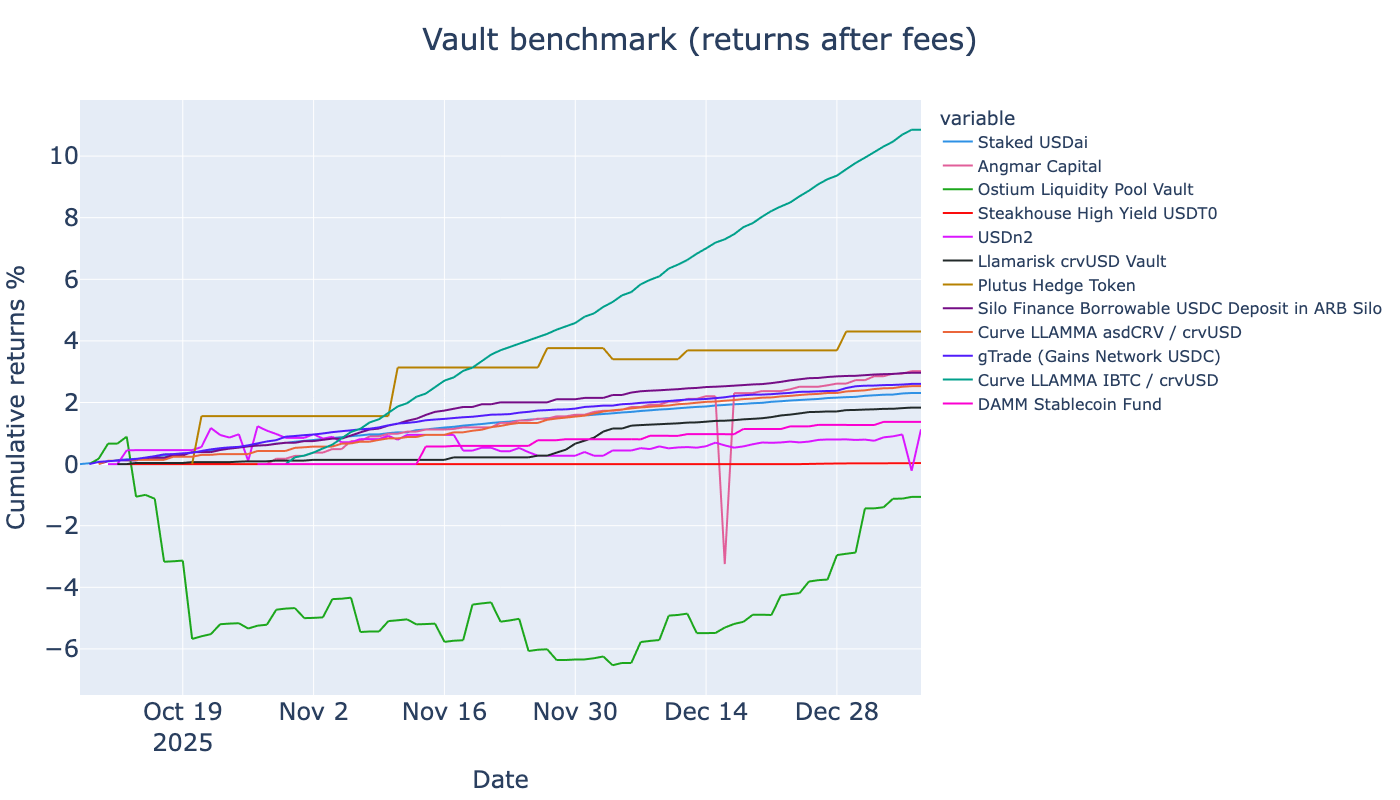

In [9]:
from eth_defi.research.vault_benchmark import visualise_vault_return_benchmark

top_count = 15

top_vaults_specs = lifetime_data_filtered_df.head(top_count)["id"].apply(VaultSpec.parse_string)

fig, net_returns_df = visualise_vault_return_benchmark(
    top_vaults_specs,
    prices_df=prices_df,
    vault_db=vault_db,
)

# display(net_returns_df)

fig.show()


## Top vaults correlation

- Check top vaults correlation matrix

In [10]:
# TODO

## Vault charts and performance tearsheets

- Show rolling returns performance chart for N top vaults

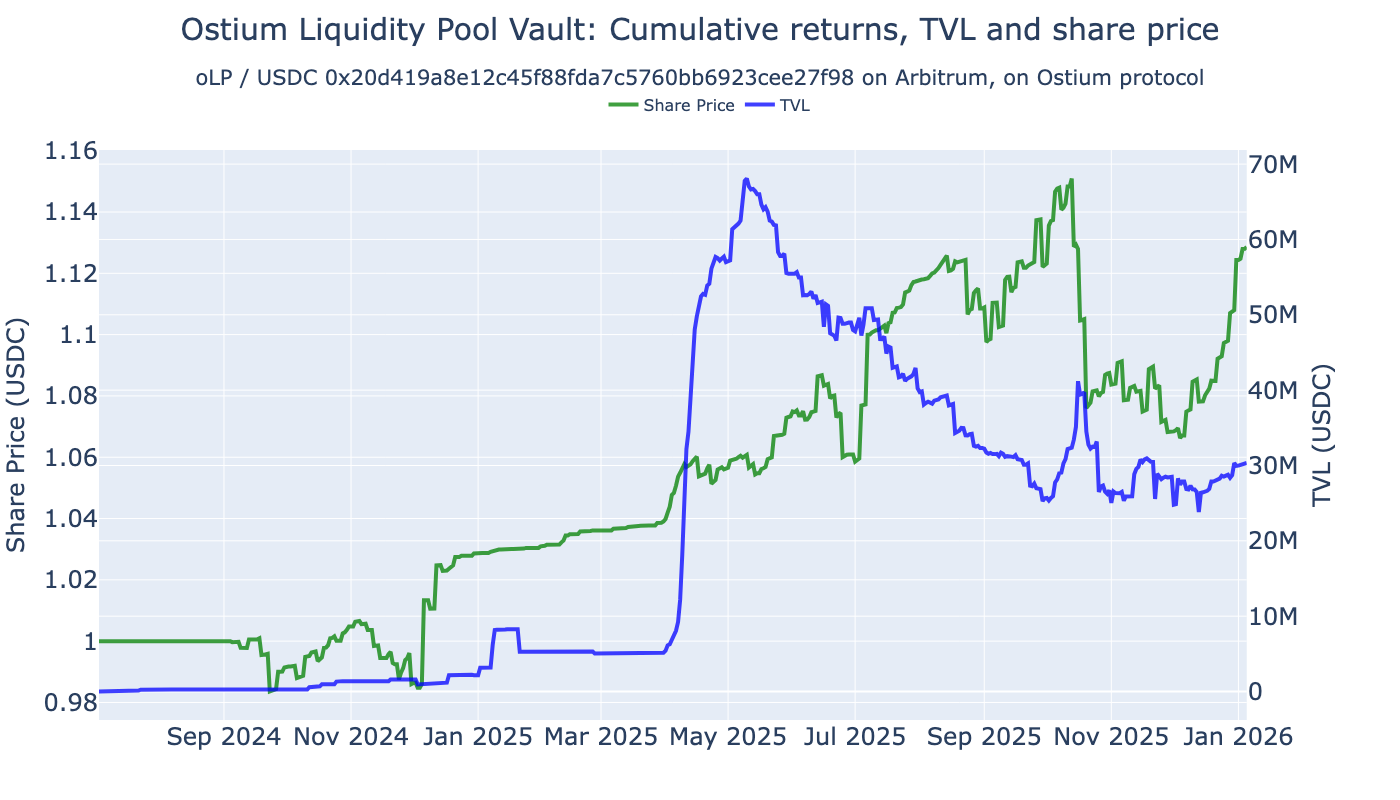

Metric,Value,Metric,Value,Metric,Value
Start,2024-07-03,End,2026-01-05,Risk-free rate,0.00%
Total Return,12.86%,CAGR,8.35%,Max Drawdown,-7.36%
Calmar Ratio,1.14,MTD,0.38%,3m,-1.57%
6m,4.77%,YTD,0.38%,1Y,9.70%
3Y (ann.),8.35%,5Y (ann.),-,10Y (ann.),-
Since Incep. (ann.),8.35%,Daily Sharpe,1.01,Daily Sortino,1.48
Daily Mean (ann.),5.69%,Daily Vol (ann.),5.66%,Daily Skew,-0.11
Daily Kurt,21.07,Best Day,2.77%,Worst Day,-2.63%
Monthly Sharpe,1.03,Monthly Sortino,2.67,Monthly Mean (ann.),8.40%
Monthly Vol (ann.),8.17%,Monthly Skew,0.71,Monthly Kurt,0.15


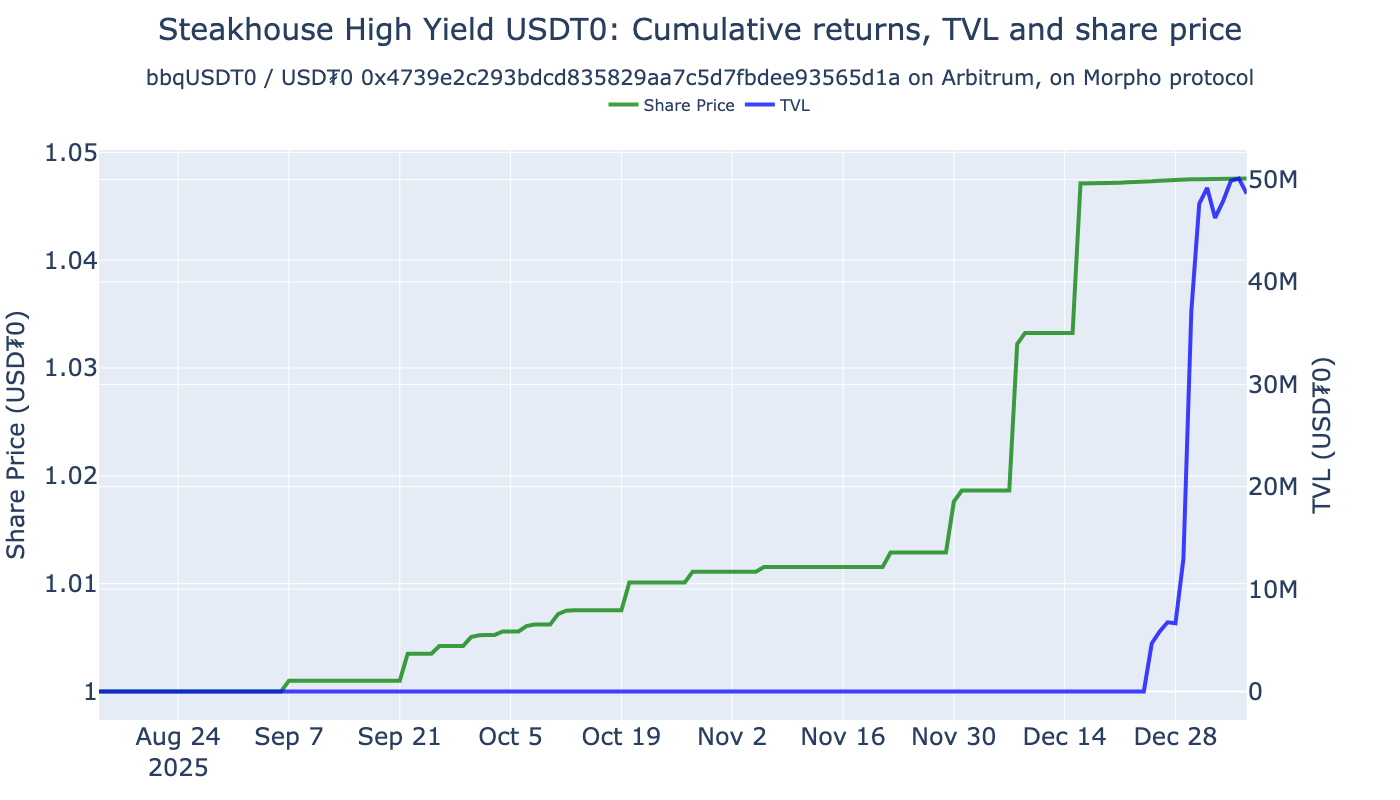

Metric,Value,Metric,Value,Metric,Value
Start,2025-08-14,End,2026-01-06,Risk-free rate,0.00%
Total Return,4.76%,CAGR,12.42%,Max Drawdown,0.00%
Calmar Ratio,inf,MTD,0.01%,3m,4.18%
6m,-,YTD,0.01%,1Y,-
3Y (ann.),-,5Y (ann.),-,10Y (ann.),-
Since Incep. (ann.),12.42%,Daily Sharpe,3.12,Daily Sortino,inf
Daily Mean (ann.),8.11%,Daily Vol (ann.),2.60%,Daily Skew,7.30
Daily Kurt,55.89,Best Day,1.34%,Worst Day,0.00%
Monthly Sharpe,2.84,Monthly Sortino,inf,Monthly Mean (ann.),11.27%
Monthly Vol (ann.),3.97%,Monthly Skew,1.95,Monthly Kurt,4.15


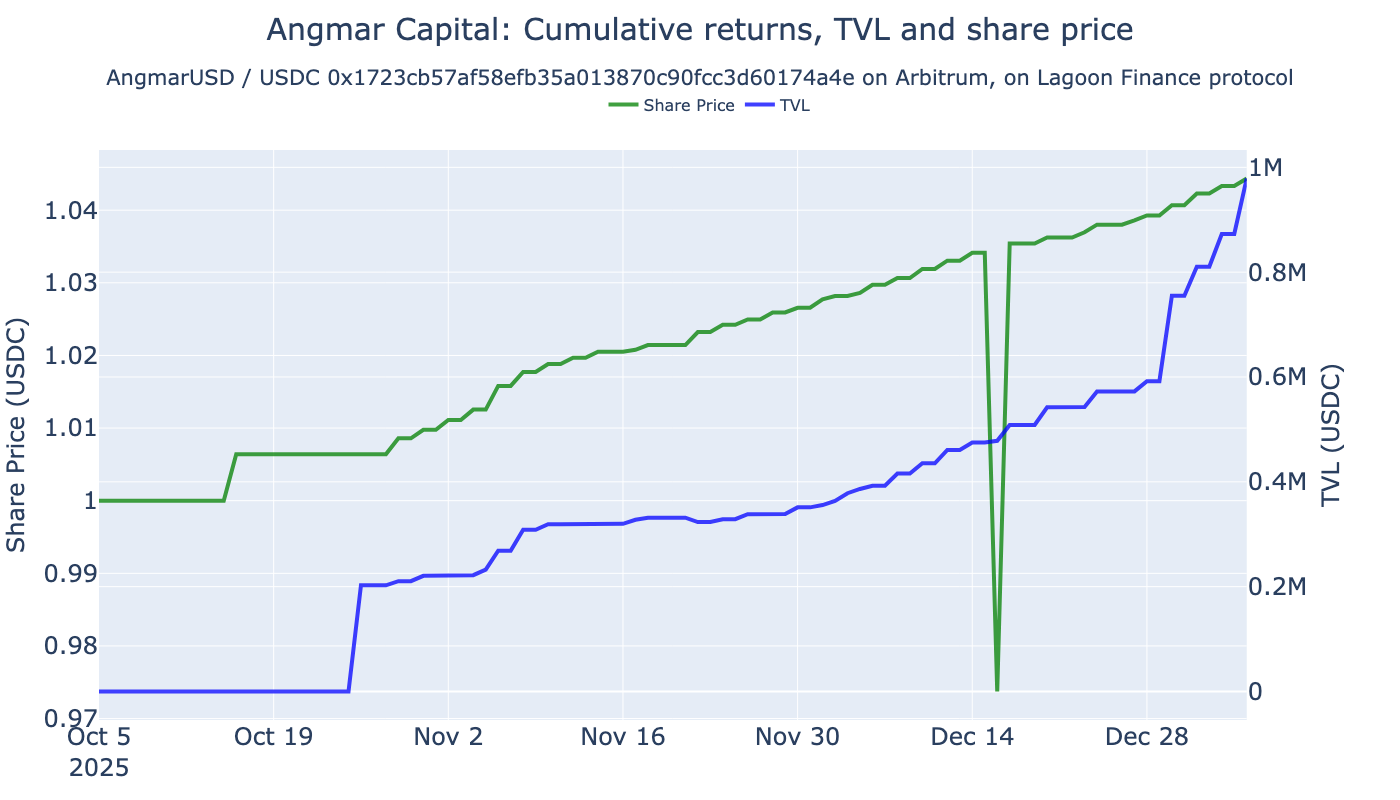

Metric,Value,Metric,Value,Metric,Value
Start,2025-10-05,End,2026-01-05,Risk-free rate,0.00%
Total Return,4.44%,CAGR,18.81%,Max Drawdown,-5.84%
Calmar Ratio,3.22,MTD,0.35%,3m,4.44%
6m,-,YTD,0.35%,1Y,-
3Y (ann.),-,5Y (ann.),-,10Y (ann.),-
Since Incep. (ann.),18.81%,Daily Sharpe,0.90,Daily Sortino,1.34
Daily Mean (ann.),12.92%,Daily Vol (ann.),14.40%,Daily Skew,0.66
Daily Kurt,44.79,Best Day,6.34%,Worst Day,-5.84%
Monthly Sharpe,5.69,Monthly Sortino,inf,Monthly Mean (ann.),13.57%
Monthly Vol (ann.),2.39%,Monthly Skew,-1.39,Monthly Kurt,-


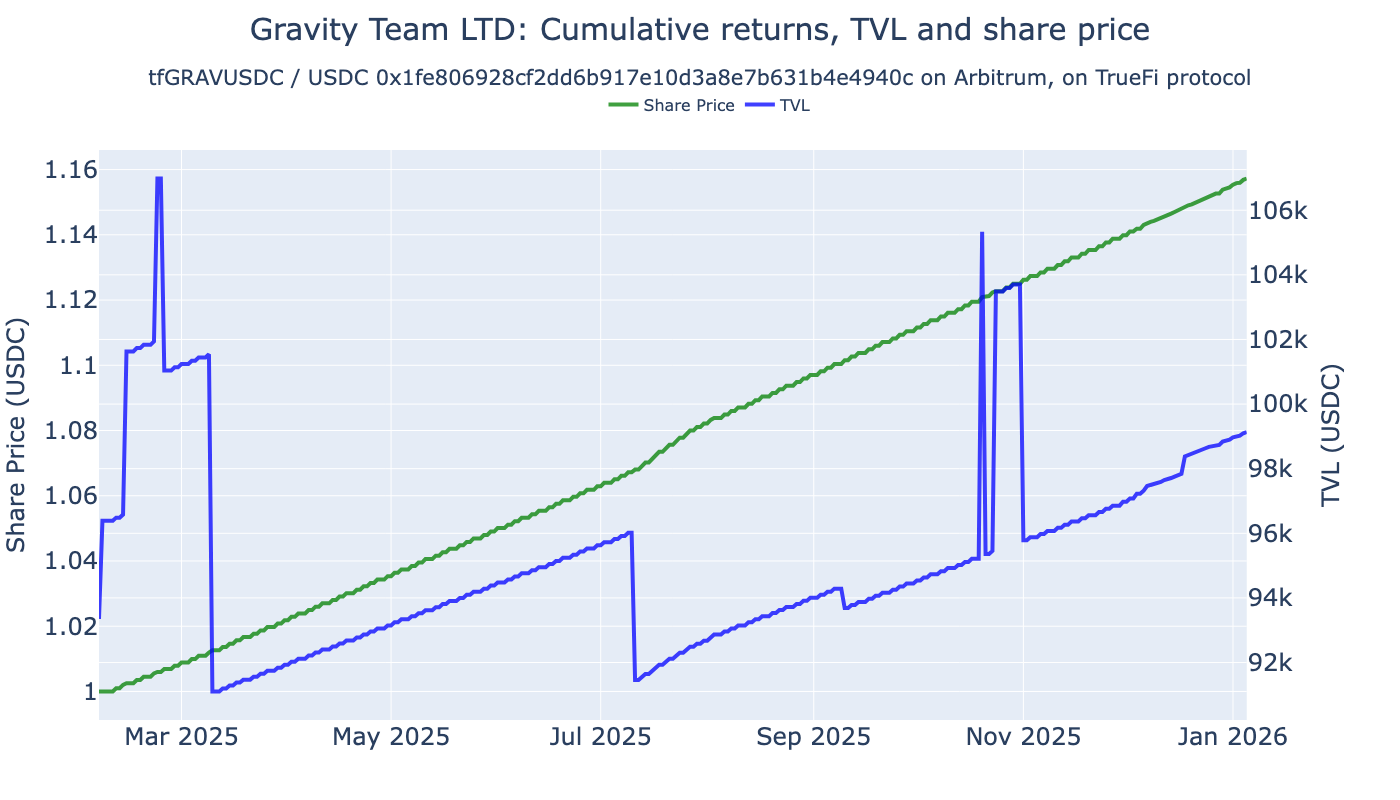

Metric,Value,Metric,Value,Metric,Value
Start,2025-02-05,End,2026-01-05,Risk-free rate,0.00%
Total Return,15.73%,CAGR,17.32%,Max Drawdown,-0.00%
Calmar Ratio,12370.84,MTD,0.24%,3m,3.90%
6m,8.66%,YTD,0.24%,1Y,-
3Y (ann.),-,5Y (ann.),-,10Y (ann.),-
Since Incep. (ann.),17.32%,Daily Sharpe,14.53,Daily Sortino,9066.60
Daily Mean (ann.),11.03%,Daily Vol (ann.),0.76%,Daily Skew,0.29
Daily Kurt,-1.82,Best Day,0.13%,Worst Day,-0.00%
Monthly Sharpe,11.70,Monthly Sortino,inf,Monthly Mean (ann.),15.18%
Monthly Vol (ann.),1.30%,Monthly Skew,-2.15,Monthly Kurt,7.12


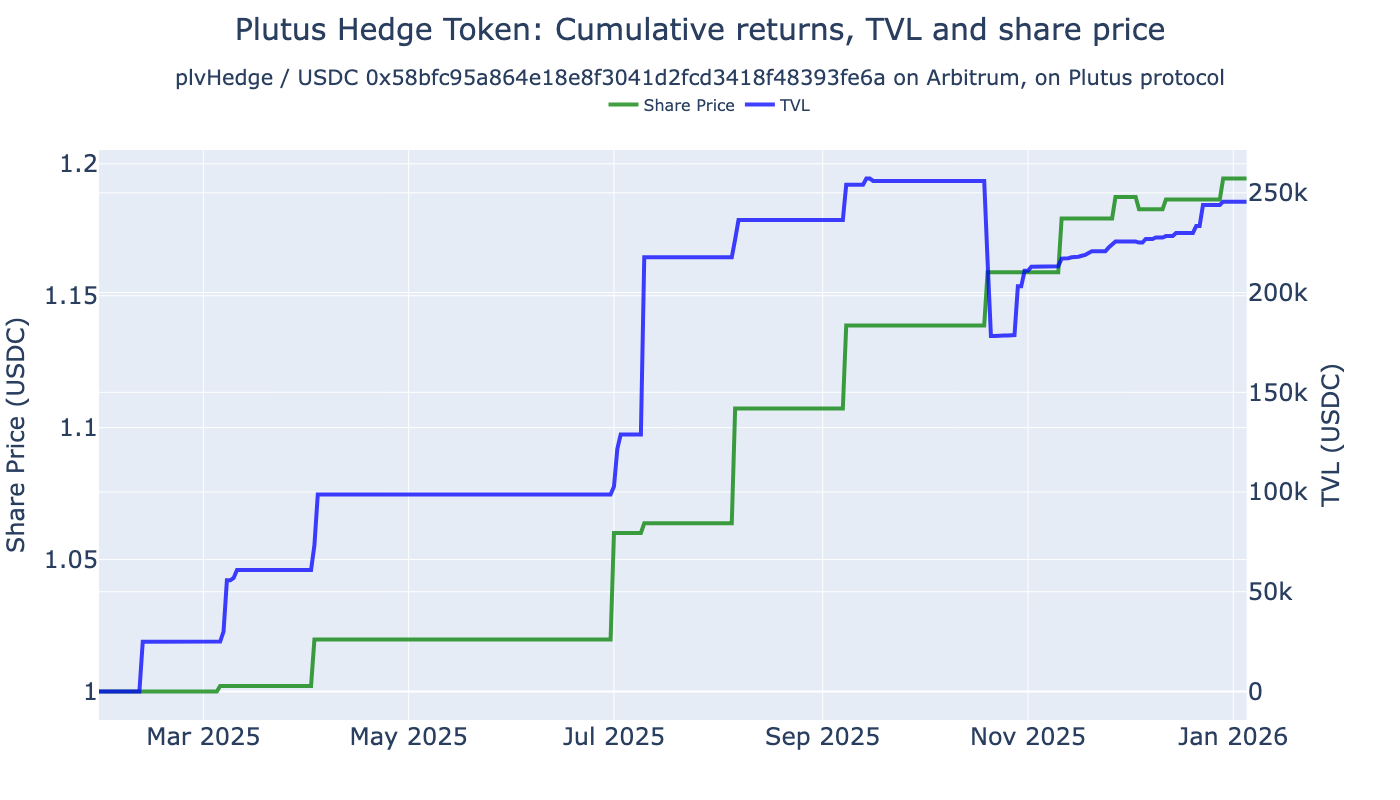

Metric,Value,Metric,Value,Metric,Value
Start,2025-01-29,End,2026-01-05,Risk-free rate,0.00%
Total Return,19.44%,CAGR,20.96%,Max Drawdown,-0.39%
Calmar Ratio,53.46,MTD,0.00%,3m,4.89%
6m,12.68%,YTD,0.00%,1Y,-
3Y (ann.),-,5Y (ann.),-,10Y (ann.),-
Since Incep. (ann.),20.96%,Daily Sharpe,2.18,Daily Sortino,39.50
Daily Mean (ann.),13.32%,Daily Vol (ann.),6.10%,Daily Skew,8.48
Daily Kurt,77.34,Best Day,4.09%,Worst Day,-0.39%
Monthly Sharpe,3.21,Monthly Sortino,inf,Monthly Mean (ann.),18.04%
Monthly Vol (ann.),5.63%,Monthly Skew,0.67,Monthly Kurt,-0.96


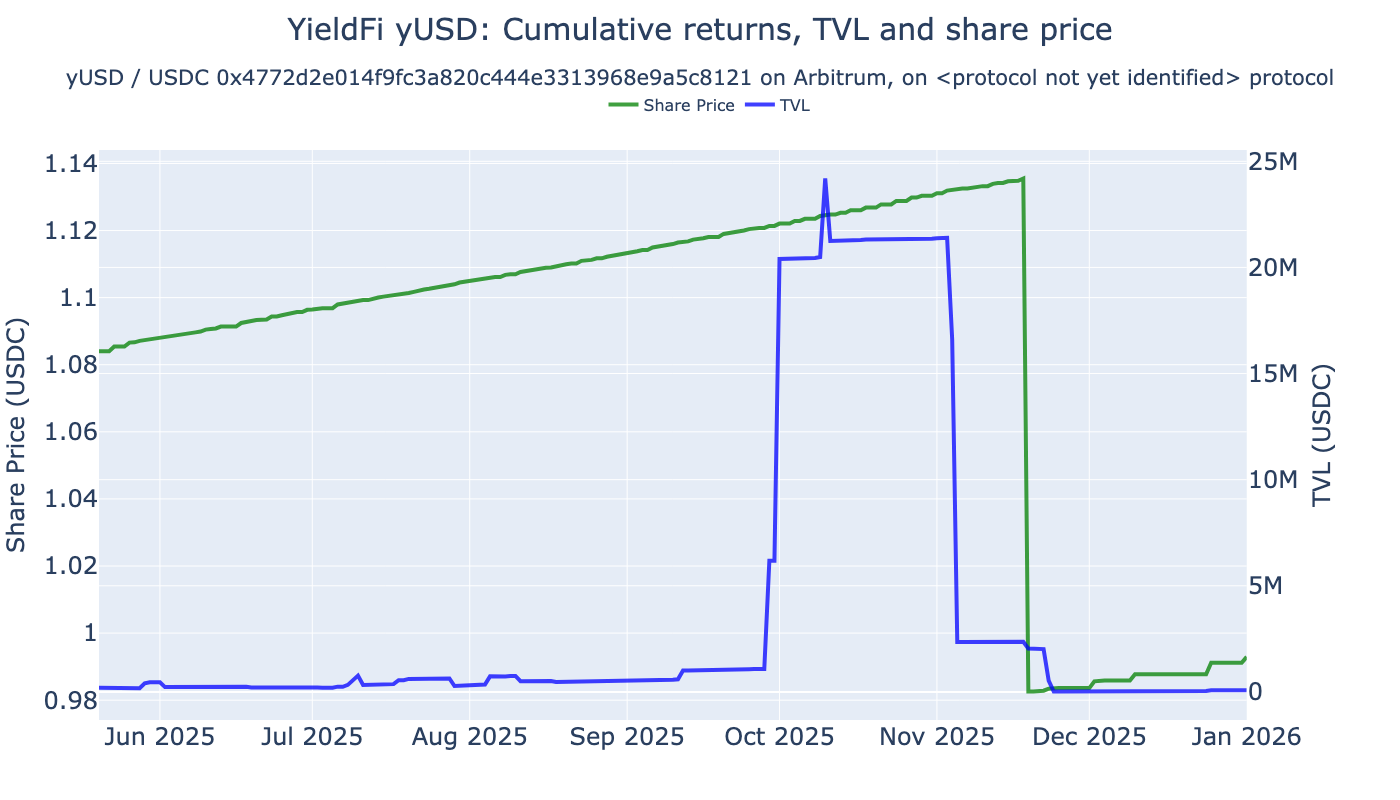

Metric,Value,Metric,Value,Metric,Value
Start,2025-05-20,End,2026-01-01,Risk-free rate,0.00%
Total Return,-8.41%,CAGR,-13.23%,Max Drawdown,-13.47%
Calmar Ratio,-0.98,MTD,0.18%,3m,-11.51%
6m,-9.45%,YTD,0.18%,1Y,-
3Y (ann.),-,5Y (ann.),-,10Y (ann.),-
Since Incep. (ann.),-13.23%,Daily Sharpe,-0.61,Daily Sortino,-0.61
Daily Mean (ann.),-8.68%,Daily Vol (ann.),14.26%,Daily Skew,-14.99
Daily Kurt,225.18,Best Day,0.35%,Worst Day,-13.47%
Monthly Sharpe,-0.73,Monthly Sortino,-0.77,Monthly Mean (ann.),-12.25%
Monthly Vol (ann.),16.76%,Monthly Skew,-2.82,Monthly Kurt,7.95


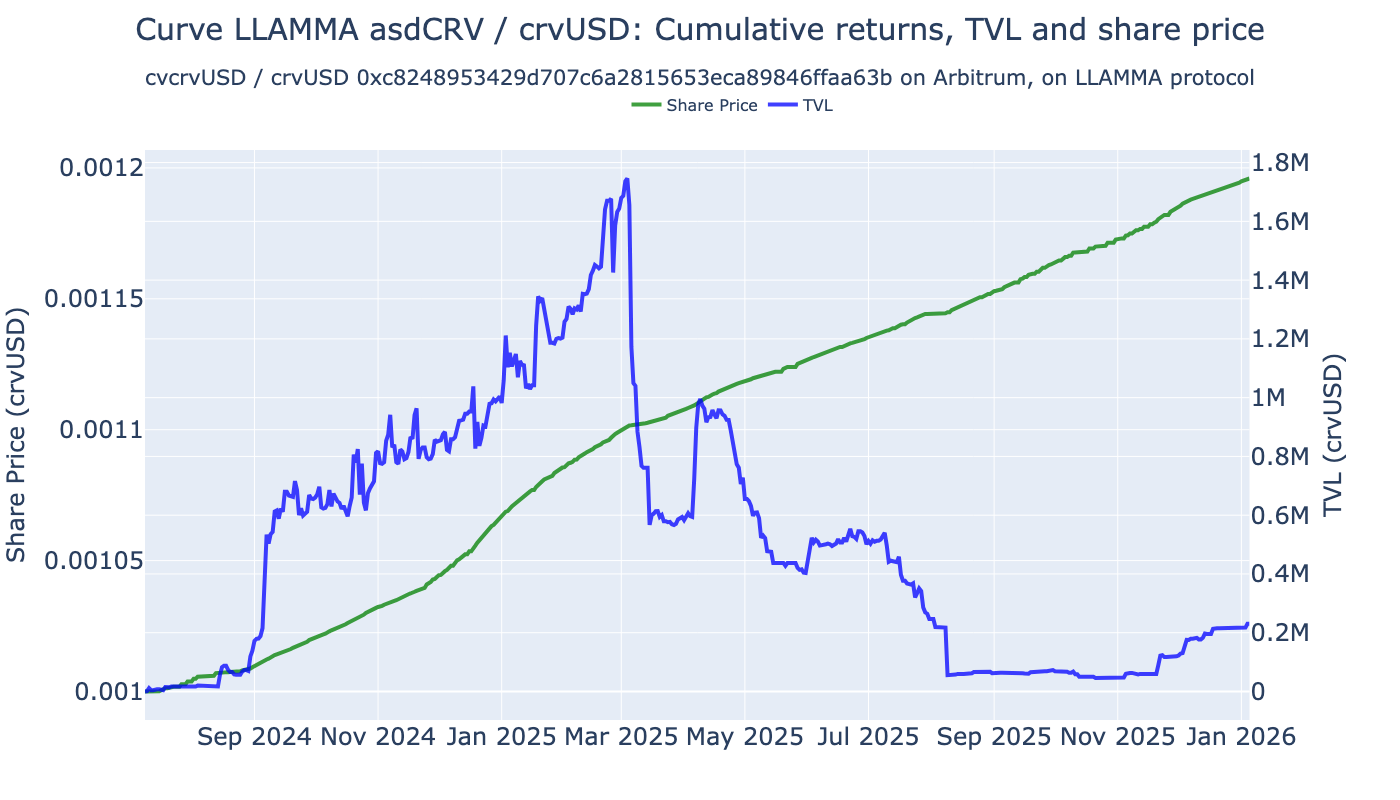

Metric,Value,Metric,Value,Metric,Value
Start,2024-07-09,End,2026-01-05,Risk-free rate,0.00%
Total Return,19.60%,CAGR,12.74%,Max Drawdown,0.00%
Calmar Ratio,inf,MTD,0.13%,3m,2.63%
6m,5.24%,YTD,0.13%,1Y,11.77%
3Y (ann.),12.74%,5Y (ann.),-,10Y (ann.),-
Since Incep. (ann.),12.74%,Daily Sharpe,19.47,Daily Sortino,inf
Daily Mean (ann.),8.28%,Daily Vol (ann.),0.43%,Daily Skew,1.01
Daily Kurt,1.11,Best Day,0.13%,Worst Day,0.00%
Monthly Sharpe,7.49,Monthly Sortino,inf,Monthly Mean (ann.),11.74%
Monthly Vol (ann.),1.57%,Monthly Skew,1.07,Monthly Kurt,2.43


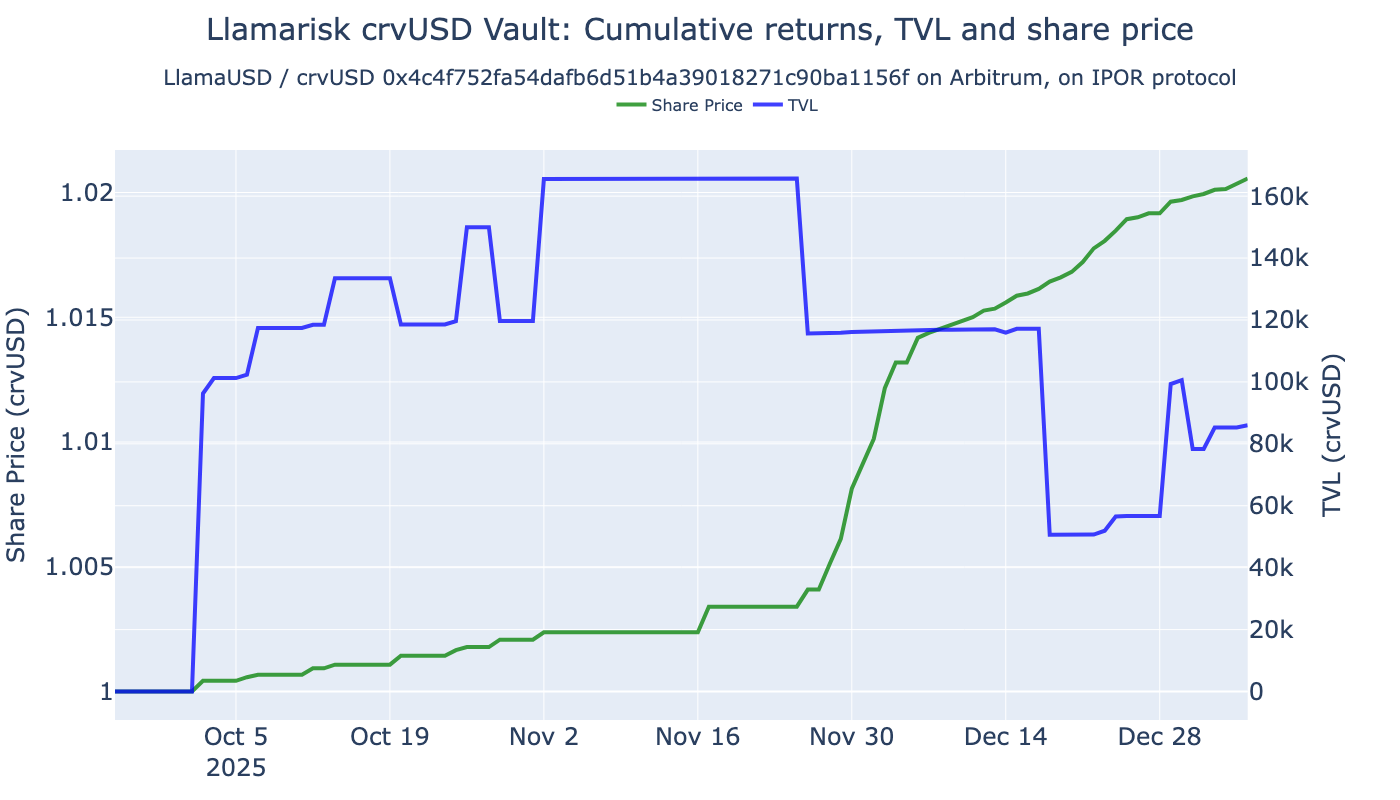

Metric,Value,Metric,Value,Metric,Value
Start,2025-09-24,End,2026-01-05,Risk-free rate,0.00%
Total Return,2.06%,CAGR,7.48%,Max Drawdown,-0.00%
Calmar Ratio,18180.85,MTD,0.07%,3m,2.01%
6m,-,YTD,0.07%,1Y,-
3Y (ann.),-,5Y (ann.),-,10Y (ann.),-
Since Incep. (ann.),7.48%,Daily Sharpe,8.47,Daily Sortino,7736.90
Daily Mean (ann.),4.98%,Daily Vol (ann.),0.59%,Daily Skew,2.99
Daily Kurt,10.33,Best Day,0.20%,Worst Day,-0.00%
Monthly Sharpe,3.62,Monthly Sortino,inf,Monthly Mean (ann.),6.13%
Monthly Vol (ann.),1.70%,Monthly Skew,0.93,Monthly Kurt,-0.38


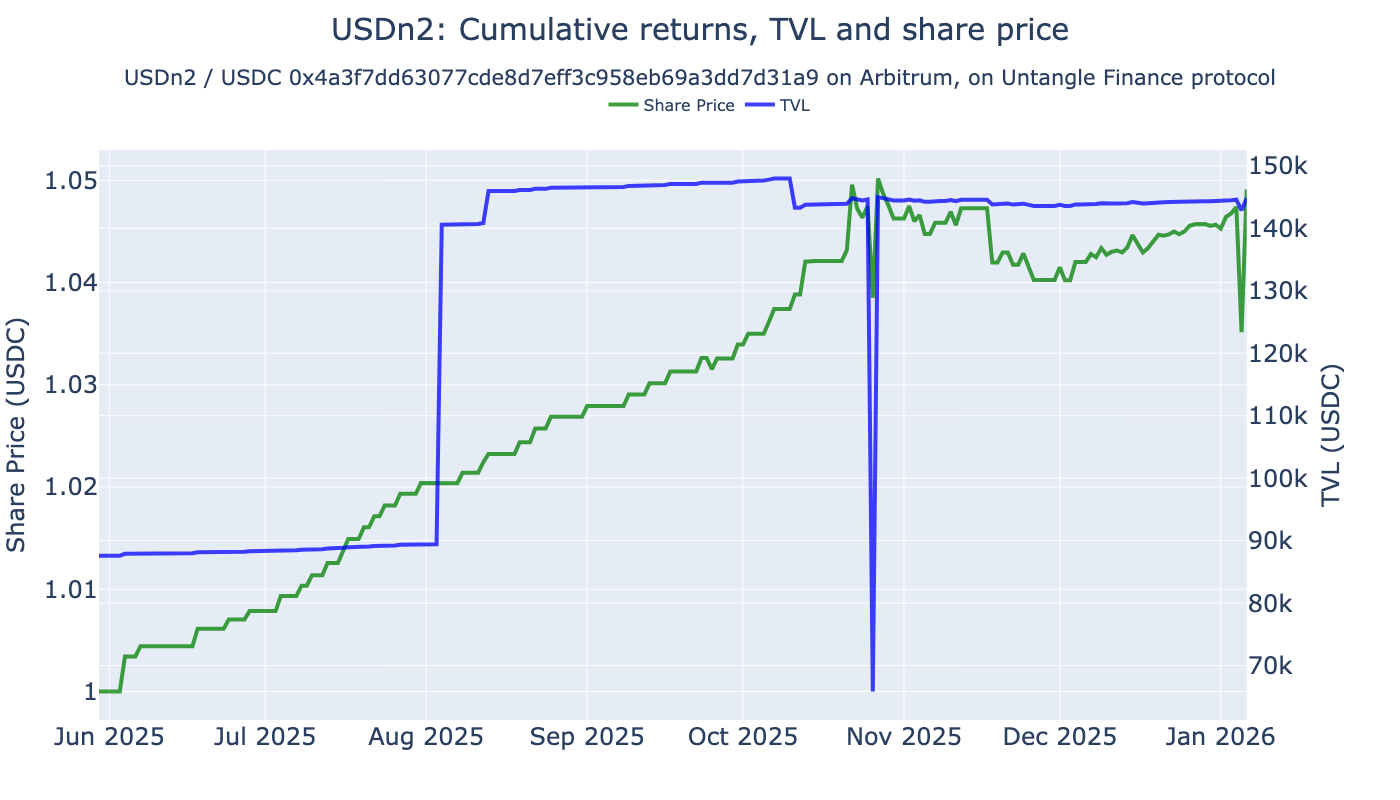

Metric,Value,Metric,Value,Metric,Value
Start,2025-05-30,End,2026-01-06,Risk-free rate,0.00%
Total Return,4.91%,CAGR,8.25%,Max Drawdown,-1.43%
Calmar Ratio,5.77,MTD,0.33%,3m,1.25%
6m,3.94%,YTD,0.33%,1Y,-
3Y (ann.),-,5Y (ann.),-,10Y (ann.),-
Since Incep. (ann.),8.25%,Daily Sharpe,1.97,Daily Sortino,3.24
Daily Mean (ann.),5.51%,Daily Vol (ann.),2.79%,Daily Skew,1.19
Daily Kurt,33.12,Best Day,1.35%,Worst Day,-1.17%
Monthly Sharpe,3.66,Monthly Sortino,10.26,Monthly Mean (ann.),7.23%
Monthly Vol (ann.),1.97%,Monthly Skew,-1.22,Monthly Kurt,2.34


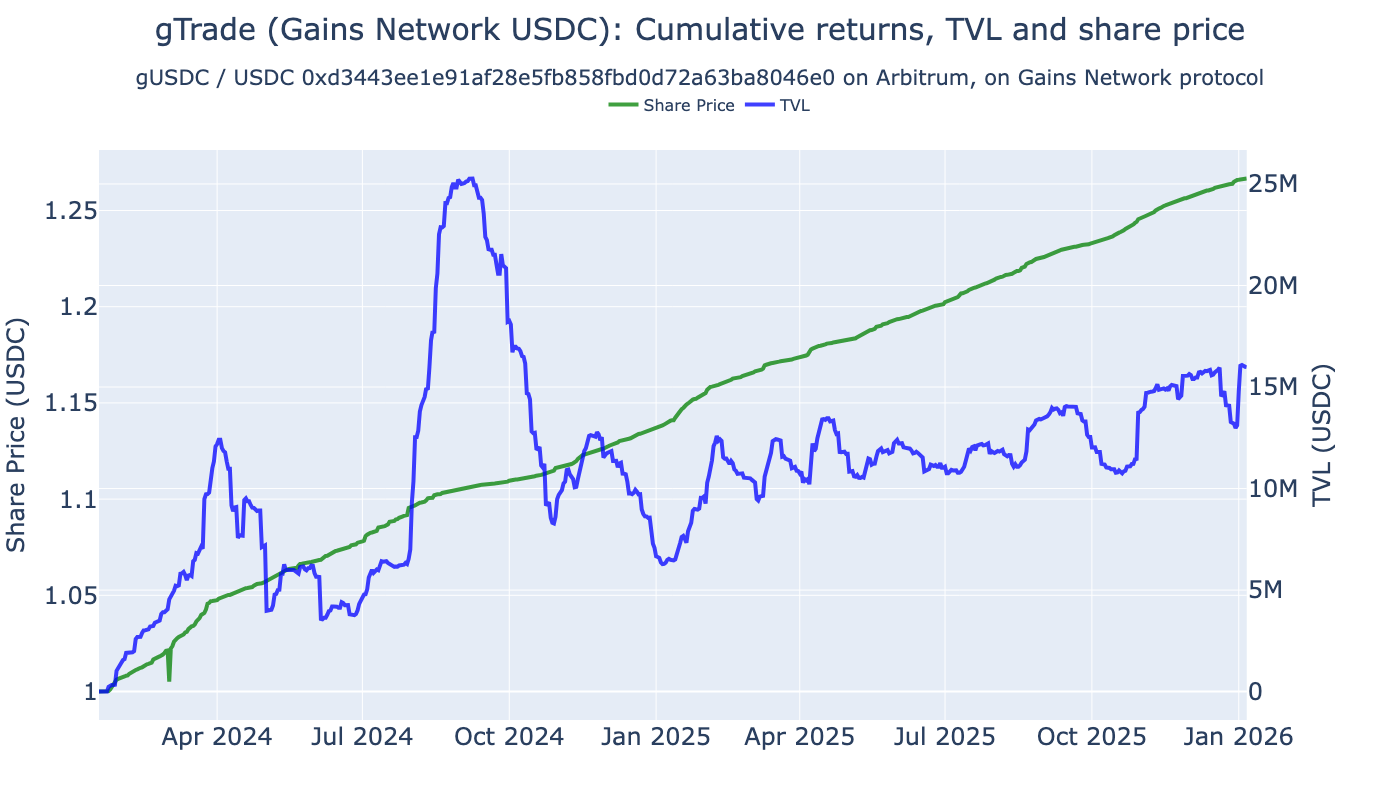

Metric,Value,Metric,Value,Metric,Value
Start,2024-01-18,End,2026-01-06,Risk-free rate,0.00%
Total Return,26.66%,CAGR,12.76%,Max Drawdown,-1.59%
Calmar Ratio,8.05,MTD,0.06%,3m,2.64%
6m,5.23%,YTD,0.06%,1Y,11.23%
3Y (ann.),12.76%,5Y (ann.),-,10Y (ann.),-
Since Incep. (ann.),12.76%,Daily Sharpe,5.59,Daily Sortino,8.84
Daily Mean (ann.),8.30%,Daily Vol (ann.),1.48%,Daily Skew,1.08
Daily Kurt,270.95,Best Day,1.72%,Worst Day,-1.59%
Monthly Sharpe,6.85,Monthly Sortino,inf,Monthly Mean (ann.),11.54%
Monthly Vol (ann.),1.68%,Monthly Skew,1.51,Monthly Kurt,4.41


In [11]:
from eth_defi.research.vault_metrics import display_vault_chart_and_tearsheet
from eth_defi.vault.risk import VaultTechnicalRisk

examined_vaults_df = lifetime_data_filtered_df.loc[lifetime_data_filtered_df["risk"] != VaultTechnicalRisk.blacklisted]

interest_vault_specs = []

for idx, row in examined_vaults_df.head(10).iterrows():

    chain_id = row["id"].split("-")[0]
    address = row["id"].split("-")[1]
    vault_spec = VaultSpec(chain_id=int(chain_id), vault_address=address)

    # Used later
    interest_vault_specs.append(vault_spec)

    display_vault_chart_and_tearsheet(
        vault_spec,
        vault_db=vault_db,
        prices_df=prices_df,
        render=True,
    )


## Rolling returns comparison

- Show rolling returns of all picked vaults

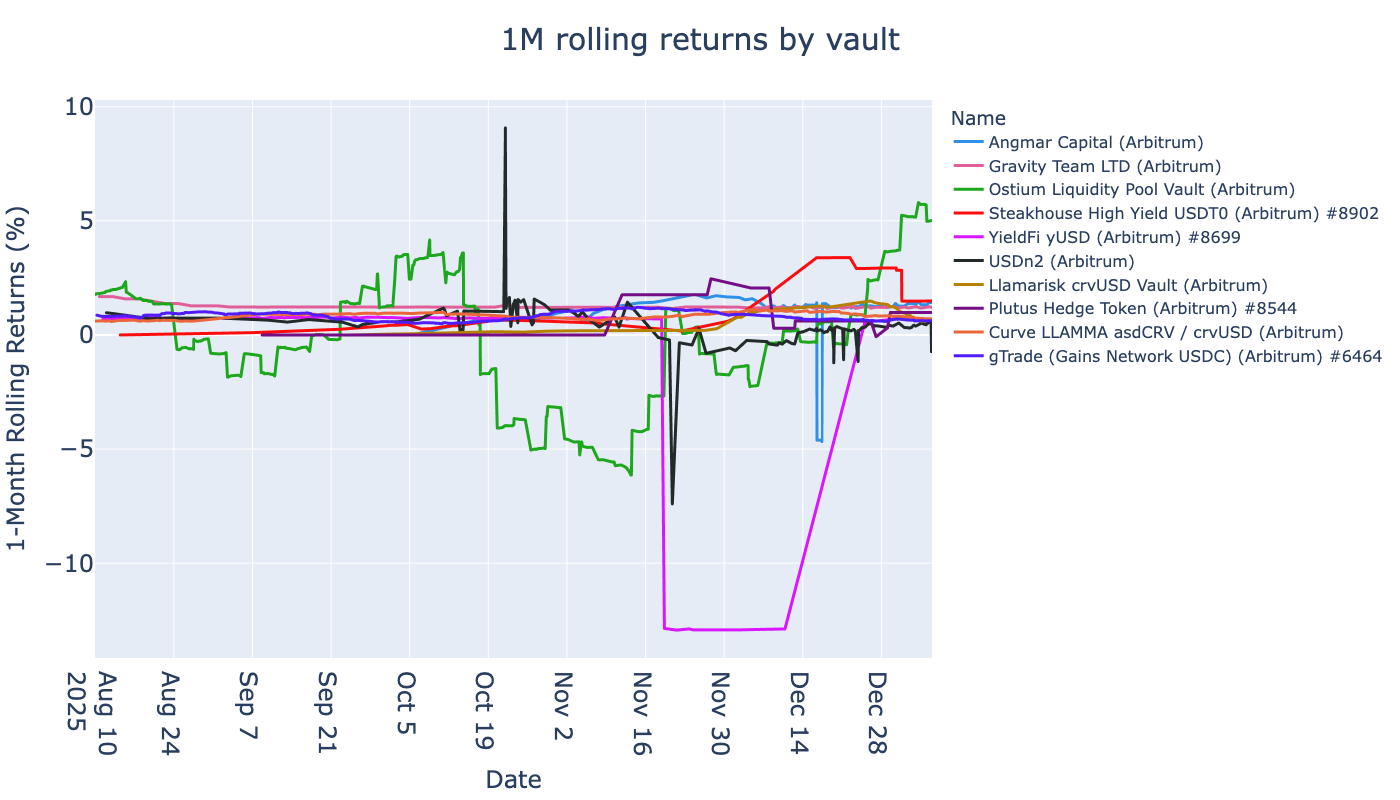

In [12]:
from eth_defi.research.rolling_returns import calculate_rolling_returns, visualise_rolling_returns

rolling_returns_df = calculate_rolling_returns(
    prices_df,
    interesting_vaults=[spec.as_string_id() for spec in interest_vault_specs],
    clip_up=100,
)

# display(rolling_returns_df.head(3))

assert len(rolling_returns_df) > 0, "No rolling returns calculated"

fig = visualise_rolling_returns(rolling_returns_df)

fig.show()

## All vaults

- List all vaults found on this chain



In [13]:
min_tvl = 1_000

lifetime_data_filtered_df = lifetime_data_df[lifetime_data_df["current_nav"] >= min_tvl]

formatted_df = format_lifetime_table(
    lifetime_data_filtered_df,
    add_index=True,
)

display(formatted_df)


,Name,Lifetime return abs. (net / gross),Lifetime return ann. (net / gross),3M return ann. (net / gross),3M sharpe,3M volatility,1M return ann. (net / gross),Denomination,Chain,TVL USD (current / peak),Age (years),Fees (mgmt / perf / dep / with),Lock up est. days,Deposit events,Protocol,Risk,id,Flags,Notes,Link
#,,,,,,,,,,,,,,,,,,,,
1,Ostium Liquidity Pool Vault,12.9% (12.9%),8.4% (8.4%),-6.7% (-6.7%),-0.3,10.8%,97.8% (97.8%),USDC,Arbitrum,"30,334,977 (68,090,578)",1.51,0% / 0%,---,"89,157",Ostium,High,42161-0x20d419a8e12c45f88fda7c5760bb6923cee27f98,,None,https://tradingstrategy.ai/trading-view/arbitr...
2,Steakhouse High Yield USDT0,4.8% (4.8%),12.5% (12.5%),17.8% (17.8%),3.0,0.6%,34.0% (34.0%),USD₮0,Arbitrum,"48,624,885 (50,137,453)",0.39,0% / 0%,0,"3,726",Morpho,Negligible,42161-0x4739e2c293bdcd835829aa7c5d7fbdee93565d1a,,None,https://tradingstrategy.ai/trading-view/arbitr...
3,Angmar Capital,3.5% (4.4%),14.8% (18.8%),14.8% (18.8%),1.0,27.5%,14.8% (18.8%),USDC,Arbitrum,"978,666 (978,666)",0.25,0% / 20%,---,140,Lagoon Finance,Unknown,42161-0x1723cb57af58efb35a013870c90fcc3d60174a4e,,None,https://tradingstrategy.ai/trading-view/arbitr...
4,Gravity Team LTD,--- (15.7%),--- (17.3%),--- (16.6%),25.7,0.3%,--- (16.3%),USDC,Arbitrum,"99,133 (106,981)",0.91,? / ?,---,108,TrueFi,Unknown,42161-0x1fe806928cf2dd6b917e10d3a8e7b631b4e4940c,,None,https://tradingstrategy.ai/trading-view/arbitr...
5,Plutus Hedge Token,19.4% (19.4%),21.0% (21.0%),17.2% (17.2%),3.8,2.4%,12.7% (12.7%),USDC,Arbitrum,"245,578 (260,514)",0.93,0% / 12% (int.),30,479,Plutus,Severe,42161-0x58bfc95a864e18e8f3041d2fcd3418f48393fe6a,,None,https://tradingstrategy.ai/trading-view/arbitr...
6,YieldFi yUSD,--- (-8.4%),--- (-13.2%),--- (-38.8%),-2.4,74.4%,--- (9.7%),USDC,Arbitrum,"80,737 (28,372,100)",0.62,? / ?,---,50,<protocol not yet identified>,Unknown,42161-0x4772d2e014f9fc3a820c444e3313968e9a5c8121,,None,https://tradingstrategy.ai/trading-view/arbitr...
7,Curve LLAMMA asdCRV / crvUSD,19.6% (19.6%),12.8% (12.8%),10.9% (10.9%),16.6,0.3%,9.2% (9.2%),crvUSD,Arbitrum,"230,700 (1,745,829)",1.49,0% / 0%,0,"14,500",LLAMMA,Low,42161-0xc8248953429d707c6a2815653eca89846ffaa63b,,None,https://tradingstrategy.ai/trading-view/arbitr...
8,Llamarisk crvUSD Vault,1.9% (2.1%),6.8% (7.5%),7.6% (8.3%),15.3,0.9%,7.9% (8.6%),crvUSD,Arbitrum,"85,982 (165,697)",0.28,0.5% / 2%,0,136,IPOR,Low,42161-0x4c4f752fa54dafb6d51b4a39018271c90ba1156f,,None,https://tradingstrategy.ai/trading-view/arbitr...
9,USDn2,4.9% (4.9%),8.3% (8.3%),4.7% (4.7%),0.3,6.9%,8.1% (8.1%),USDC,Arbitrum,"144,809 (155,385)",0.60,0% / 0%,---,305,Untangle Finance,Low,42161-0x4a3f7dd63077cde8d7eff3c958eb69a3dd7d31a9,,None,https://tradingstrategy.ai/trading-view/arbitr...
